S# EfficientNet-B0 with Self Attention, Entropy Filtering, Ordinal Loss, and Focal Loss

This notebook trains an EfficientNet-B0 model with **self attention mechanism** combined with:
- **Self Attention**: Allows the model to focus on important spatial features
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance

The self attention mechanism helps the model learn which spatial regions of the extracted features are most important for classification.

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../../')
from utils.dataset import PandasDataset

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 2
num_workers = 1
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-attention.pth'
log_path = 'logs/b0-entropy-ordinal-focal-attention.txt'

Using device: cuda


## Self Attention Module

The self attention mechanism computes attention weights for spatial features, allowing the model to focus on the most relevant regions.

In [3]:
class SelfAttention(nn.Module):
    """
    Self Attention module for spatial feature maps.
    
    Given input feature maps of shape (batch, channels, height, width),
    computes attention weights and returns attended features.
    """
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        
        # Reduce channels for computational efficiency
        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        
        # Learnable scaling parameter
        self.gamma = nn.Parameter(torch.zeros(1))
        
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, x):
        """
        Args:
            x: Input feature maps (batch, channels, height, width)
        
        Returns:
            out: Attention-weighted features (batch, channels, height, width)
            attention: Attention weights (batch, H*W, H*W)
        """
        batch_size, channels, height, width = x.size()
        
        # Generate query, key, value projections
        # Query: (batch, C', H, W) -> (batch, H*W, C')
        query = self.query_conv(x).view(batch_size, -1, height * width).permute(0, 2, 1)
        
        # Key: (batch, C', H, W) -> (batch, C', H*W)
        key = self.key_conv(x).view(batch_size, -1, height * width)
        
        # Value: (batch, C, H, W) -> (batch, C, H*W)
        value = self.value_conv(x).view(batch_size, -1, height * width)
        
        # Compute attention scores: (batch, H*W, H*W)
        attention = torch.bmm(query, key)  # Matrix multiplication
        attention = self.softmax(attention)  # Normalize across spatial locations
        
        # Apply attention to values: (batch, C, H*W)
        out = torch.bmm(value, attention.permute(0, 2, 1))
        
        # Reshape back to spatial dimensions: (batch, C, H, W)
        out = out.view(batch_size, channels, height, width)
        
        # Residual connection with learnable weight
        out = self.gamma * out + x
        
        return out, attention

## EfficientNet with Self Attention

In [4]:
class EfficientNetWithAttention(nn.Module):
    """
    EfficientNet-B0 with Self Attention mechanism.
    
    Adds self attention after the feature extraction layers,
    before the final classification head.
    """
    def __init__(self, base_model, output_dimensions=5, dropout_rate=0.5):
        super(EfficientNetWithAttention, self).__init__()
        
        # Feature extractor (all layers except classifier)
        self.features = base_model.features
        
        # Get number of features from the last conv layer
        # EfficientNet-B0 has 1280 output channels
        num_features = 1280
        
        # Self attention module
        self.attention = SelfAttention(num_features)
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier head
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(num_features, output_dimensions)
    
    def forward(self, x):
        # Extract features: (batch, 1280, H, W)
        features = self.features(x)
        
        # Apply self attention
        attended_features, attention_weights = self.attention(features)
        
        # Global average pooling: (batch, 1280, 1, 1)
        pooled = self.avgpool(attended_features)
        
        # Flatten: (batch, 1280)
        pooled = torch.flatten(pooled, 1)
        
        # Apply dropout and classifier
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        
        return logits

## Combined Ordinal + Focal Loss

In [5]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Calculate binary cross entropy (without reduction)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Calculate p_t: probability of correct class
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate focal weight: (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=5):
    """Convert categorical labels to ordinal encoding."""
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """Convert ordinal predictions back to class labels."""
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(alpha=focal_alpha, gamma=focal_gamma)
print(f"Ordinal + Focal Loss initialized")
print(f"  Alpha: {focal_alpha}")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized
  Alpha: 0.25
  Gamma: 2.0


## Load Data with Entropy Filtering

In [6]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """Remove rows from df where the image does not exist in images_dir."""
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [7]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [8]:
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 3537
Validation batches: 884
Test batches: 795


## Model Setup with Self Attention

In [9]:
# Load pre-trained EfficientNet-B0
base_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Create model with self attention
model = EfficientNetWithAttention(
    base_model=base_model,
    output_dimensions=output_classes,
    dropout_rate=dropout_rate
)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")
print(f"Self Attention: Enabled")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6
Self Attention: Enabled


## Optimizer and Scheduler

In [10]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [11]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """Perform one training epoch."""
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """Perform validation."""
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [12]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with Self Attention + Ordinal + Focal Loss...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training with Self Attention + Ordinal + Focal Loss...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [02:36<00:00,  5.65it/s]



Results:
  Train Loss: 0.02555
  Val Loss: 0.01924
  Val Accuracy: 58.18%
  Val Kappa: 0.8077
  Val F1: 0.5177
  Learning Rate: 0.0003000

  Best model saved! Kappa: 0.8077

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [02:26<00:00,  6.05it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.02171
  Val Loss: 0.02000
  Val Accuracy: 57.27%
  Val Kappa: 0.8120
  Val F1: 0.4963
  Learning Rate: 0.0003003

  Best model saved! Kappa: 0.8120

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.01479
  Val Loss: 0.01663
  Val Accuracy: 65.25%
  Val Kappa: 0.8429
  Val F1: 0.5806
  Learning Rate: 0.0002280

  No improvement for 5 epoch(s)

Epoch 19/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [02:39<00:00,  5.54it/s]



Results:
  Train Loss: 0.01474
  Val Loss: 0.01708
  Val Accuracy: 65.59%
  Val Kappa: 0.8460
  Val F1: 0.5793
  Learning Rate: 0.0002196

  No improvement for 6 epoch(s)

Epoch 20/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [02:27<00:00,  6.00it/s]


Results:
  Train Loss: 0.01446
  Val Loss: 0.01704
  Val Accuracy: 65.99%
  Val Kappa: 0.8405
  Val F1: 0.5869
  Learning Rate: 0.0002109

  No improvement for 7 epoch(s)

Early stopping at epoch 20
Best epoch: 13 with Kappa: 0.8516

Training completed!
Best validation Kappa: 0.8516 at epoch 13


## Plot Training History

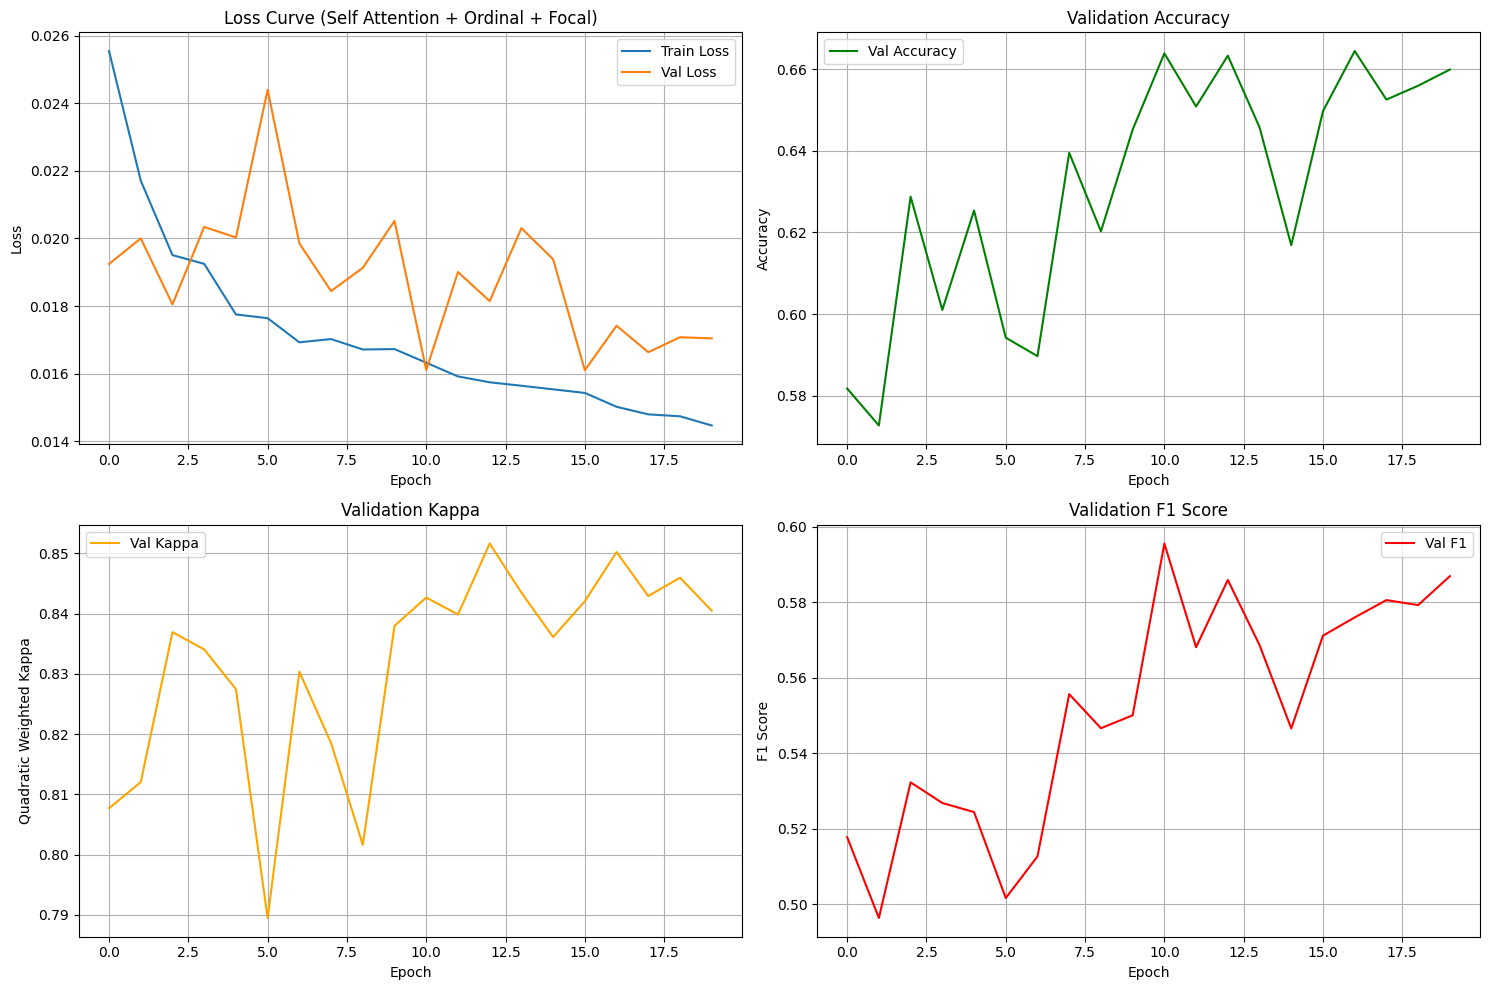

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Self Attention + Ordinal + Focal)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-attention-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 795/795 [01:49<00:00,  7.28it/s]



TEST SET RESULTS (Self Attention + Ordinal + Focal Loss)
Accuracy: 66.60%
Quadratic Weighted Kappa: 0.8337
Macro F1 Score: 0.5977

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.7922    0.9401    0.8599       434
      ISUP 1     0.7398    0.7250    0.7323       400
      ISUP 2     0.4972    0.4500    0.4724       200
      ISUP 3     0.4790    0.4324    0.4545       185
      ISUP 4     0.5145    0.3797    0.4369       187
      ISUP 5     0.6091    0.6522    0.6299       184

    accuracy                         0.6660      1590
   macro avg     0.6053    0.5966    0.5977      1590
weighted avg     0.6516    0.6660    0.6555      1590


Confusion Matrix:
[[408  14   2   2   7   1]
 [ 65 290  42   2   1   0]
 [ 11  65  90  25   7   2]
 [  9  12  33  80  29  22]
 [ 13   9   9  33  71  52]
 [  9   2   5  25  23 120]]


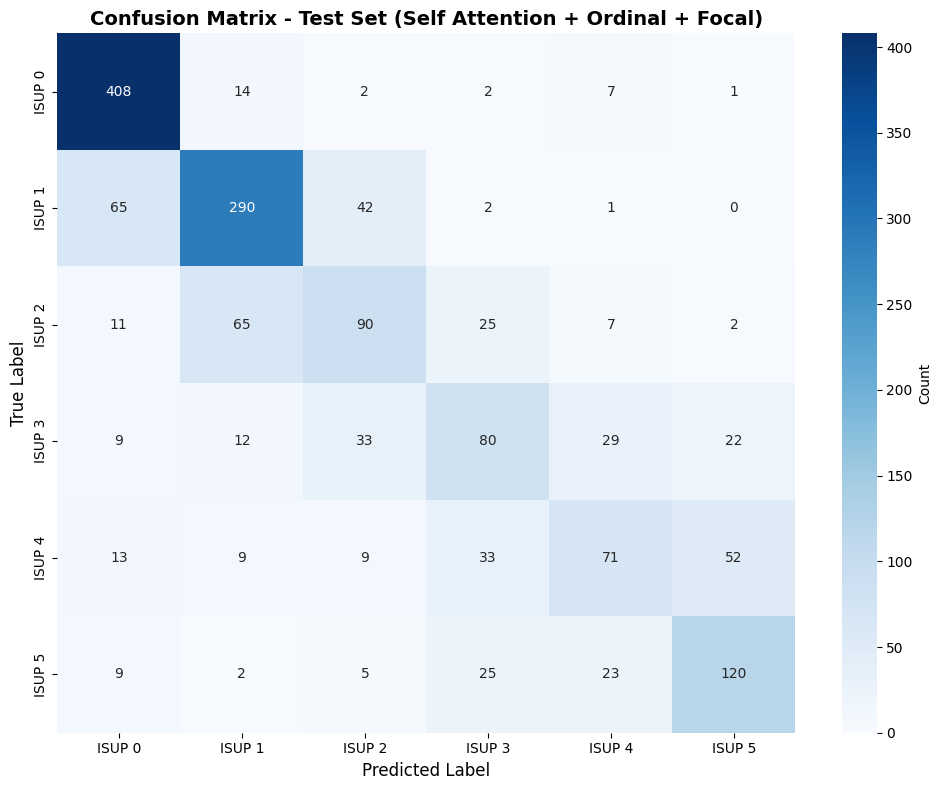


Test results saved to logs/b0-entropy-ordinal-focal-attention-test-results.txt


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Self Attention + Ordinal + Focal Loss)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Self Attention + Ordinal + Focal)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-attention-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('logs/b0-entropy-ordinal-focal-attention-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Self Attention, Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-attention-test-results.txt")

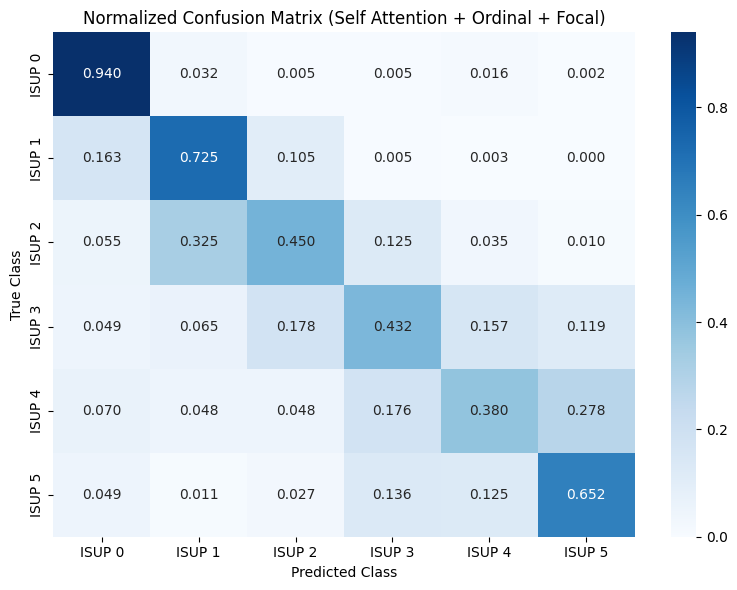

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels for classes
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Normalized Confusion Matrix (Self Attention + Ordinal + Focal)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-attention-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

This notebook trained EfficientNet-B0 with a powerful combination of techniques:

1. **Self Attention** - Allows the model to learn which spatial features are most important
2. **Entropy filtering** - Removed top 20% most difficult/ambiguous samples for cleaner training
3. **Ordinal loss** - Enforced the natural ordering of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
4. **Focal loss** - Down-weighted easy examples and focused learning on hard misclassifications

### How Self Attention helps:

- Computes attention weights for different spatial locations in feature maps
- Learns to focus on discriminative regions (e.g., areas with cancer patterns)
- Provides a weighted combination of features based on importance
- Uses a learnable scaling parameter (gamma) to balance attention with original features

### Expected benefits:

- Better spatial feature discrimination
- Improved performance on subtle patterns
- More interpretable focus on important regions
- Combined with ordinal+focal loss for handling class imbalance and ordering